In [1]:
import helper_pfop as hpop

import pandas as pd
import numpy as np
import math

In [ ]:
u = [0.08, 0.1, 0.12]
beta = 0.015
betas = [0.75 * beta, 0.5 * beta, 0.25 * beta]
phi = 0.75
r = 0.05
alpha = 0.05

T = 8.0
# x = np.linspace(0.0, T, 1000)

x = hpop.time_grid_df(T, n=10000)

vt = np.array([[0.2, 0.0, 0.0],
                   [0.0, 0.25, 0.0],
                   [0.0, 0.0, 0.3]], dtype=float)

rhot = np.array([[1.0,  -0.6,  -0.8],
                     [-0.6,  1.0,  0.5],
                     [-0.8, 0.5,  1.0]], dtype=float)

leftside = np.linalg.inv(vt) @ np.linalg.inv(rhot) @ np.linalg.inv(vt)

In [3]:
b_all = [hpop.b_stock(u[i], betas[i], phi, x) for i in range(len(u))]
b_df = pd.concat(b_all, axis=1)
b_df.columns = [f"b_{i+1}" for i in range(len(b_all))]

B = hpop.B_t(b_df, r)

cov_target = vt @ rhot @ vt
theta = hpop.theta_norm_from_df(B, T = T, Cov = cov_target)
A = hpop.inthelog(T = 8)

epsilon_stern = hpop.solve_epsilon(theta, alpha = alpha, A = A)
optimal_strategies_for_min_risk = hpop.opt_strategy(epsilon_stern, theta, cov_target, B)

epsilon_stern_avar = hpop.solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha)
optimal_strategies_for_min_risk_avar = hpop.opt_strategy(epsilon_stern_avar, theta, cov_target, B)

epsilon_stern_lel = hpop.solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha, lel = True)
optimal_strategies_for_min_risk_lel = hpop.opt_strategy(epsilon_stern_lel, theta, cov_target, B)

In [4]:
# for the min risk for given expected wealth
M = 5
X0 = 1
chi = math.log(M / (X0 * np.exp(r * T)))
optimal_strategies_for_min_risk_given_M = hpop.opt_strategy(chi, theta, cov_target, B)

In [ ]:
optimal_strategies_for_min_risk = hpop.prep_r_col(optimal_strategies_for_min_risk)
optimal_strategies_for_min_risk_avar = hpop.prep_r_col(optimal_strategies_for_min_risk_avar)
optimal_strategies_for_min_risk_lel = hpop.prep_r_col(optimal_strategies_for_min_risk_lel)
optimal_strategies_for_min_risk_given_M = hpop.prep_r_col(optimal_strategies_for_min_risk_given_M)

ak1, ak2, ak3, rfr = hpop.split_3dfs_into_4dfs_var_avar_lel(optimal_strategies_for_min_risk,
                                optimal_strategies_for_min_risk_avar, optimal_strategies_for_min_risk_lel)

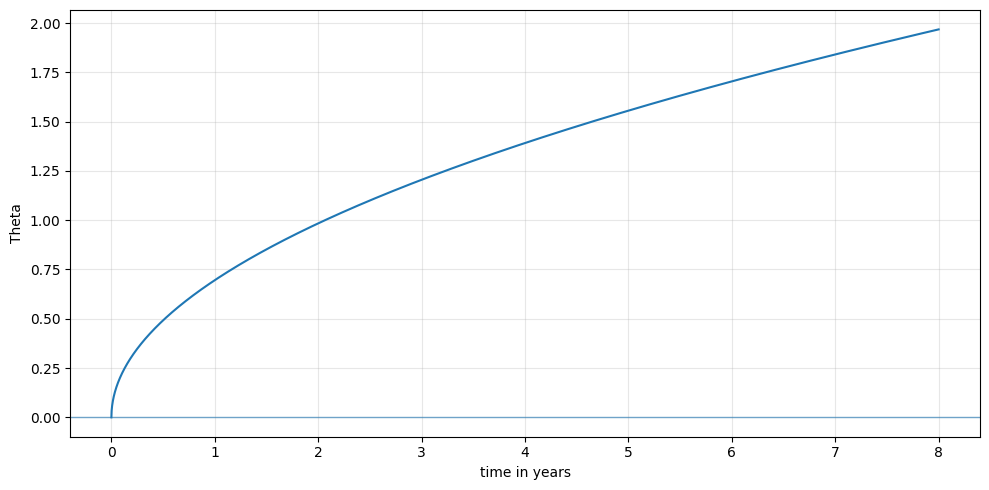

In [7]:
hpop.plot_theta(B, cov_target)

In [8]:
t = np.linspace(0.0, T, 10000)
X0 = 1
ew = [hpop.expected_wealth(epsilon_stern, X0 = 1, r = r, T = ti, B_df = B, covariance = cov_target) for ti in t]
ew_avar = [hpop.expected_wealth(epsilon_stern_avar, X0 = 1, r = r, T = ti, B_df = B, covariance = cov_target) for ti in t]
ew_lel = [hpop.expected_wealth(epsilon_stern_lel, X0 = 1, r = r, T = ti, B_df = B, covariance = cov_target) for ti in t]
e_wealth = pd.DataFrame({
    "VaR": ew,
    "AVaR": ew_avar,
    "LEL": ew_lel
})

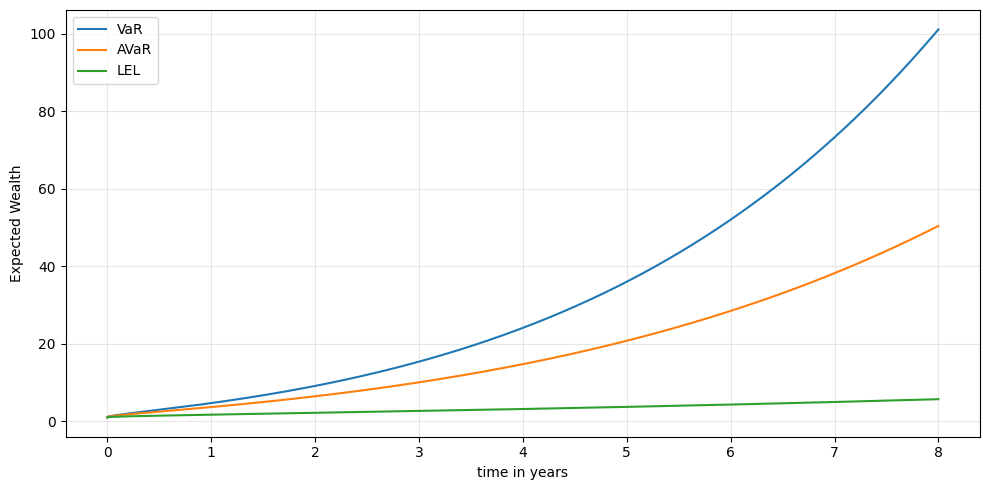

In [9]:
hpop.plot_helper(e_wealth, ylabel = "Expected Wealth")

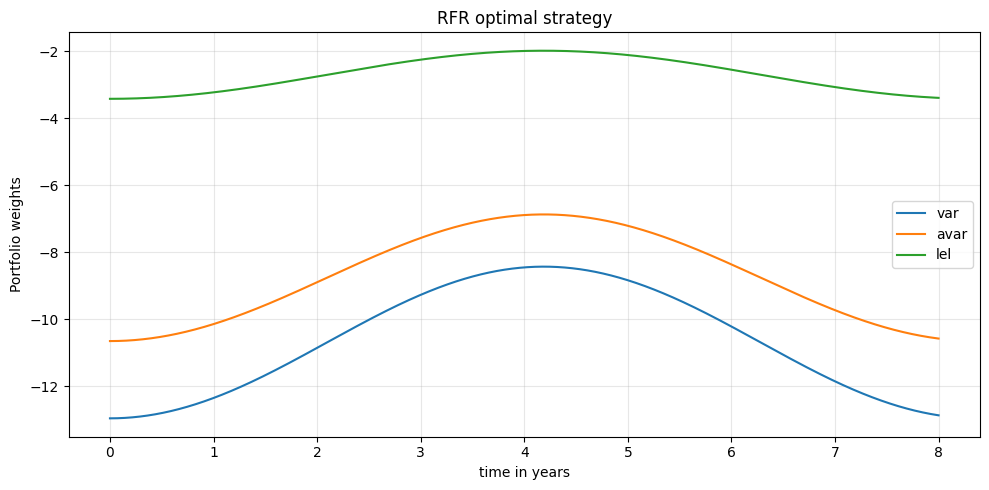

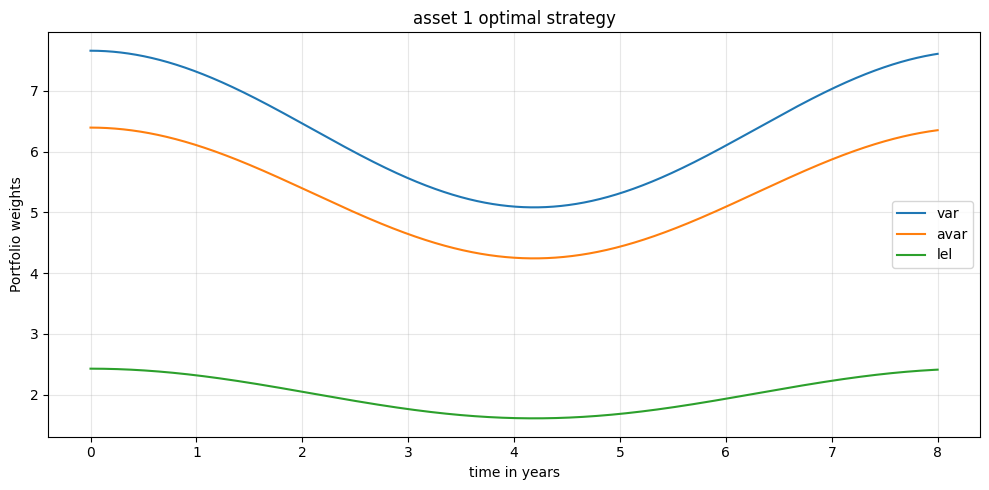

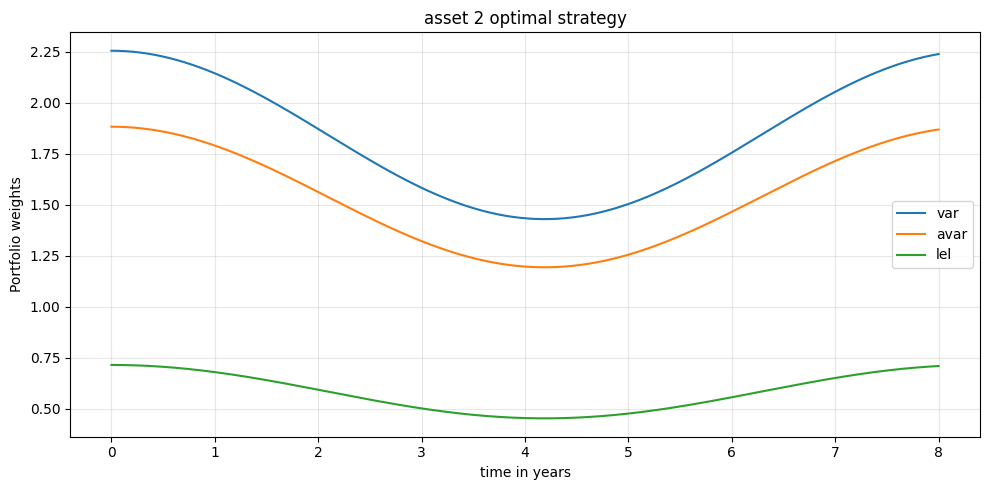

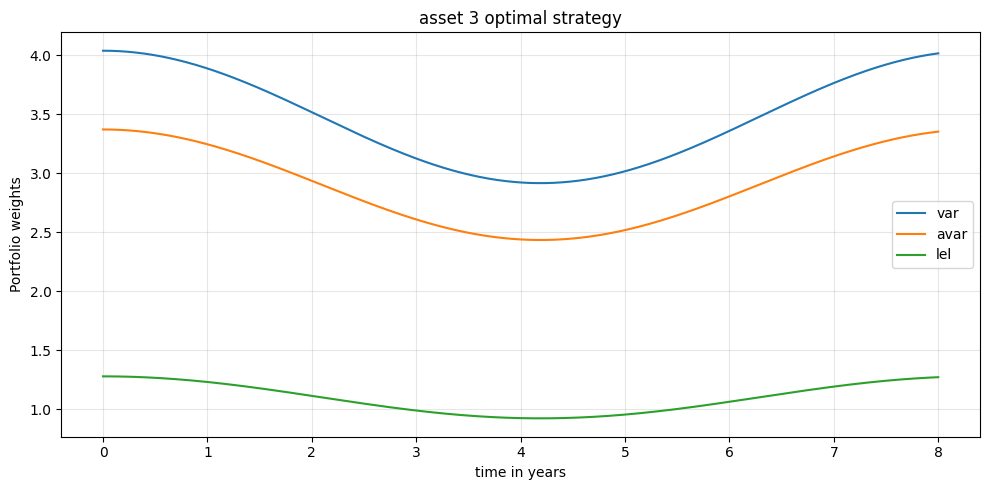

In [10]:
hpop.plot_helper(rfr, title= "RFR optimal strategy")
hpop.plot_helper(ak1, title= "asset 1 optimal strategy")
hpop.plot_helper(ak2, title= "asset 2 optimal strategy")
hpop.plot_helper(ak3, title= "asset 3 optimal strategy")